# Лабораторная работа 7
## Деревья
### **(20 баллов)**

### № 1
#### **(3 балла)**
a) Перепишите функции buildParseTree и evaluate из лекционных материалов так, чтобы они работали с логическими выражениями, то есть с операторами «и», «или», «не» и операндами «истина» и «ложь». Помните, что «не» – унарный оператор.

b) Реализуйте функцию printexp, которая будет принимать дерево синтаксического разбора и возвращать строку соответствующего ему логического выражения.

In [23]:
# === ИЗ ЛЕКЦИИ
class Stack:
    def __init__(self):
        self.items = []

    def isEmpty(self):
        return self.items == []

    def push(self, item):
        self.items.append(item)

    def pop(self):
        return self.items.pop()

    def peek(self):
        return self.items[-1]

    def size(self):
        return len(self.items)


class BinaryTree:
    def __init__(self, rootObj):
        self.key = rootObj
        self.leftChild = None
        self.rightChild = None

    def insertLeft(self, newNode):
        if self.leftChild == None:
            self.leftChild = BinaryTree(newNode)
        else:
            t = BinaryTree(newNode)
            t.leftChild = self.leftChild
            self.leftChild = t

    def insertRight(self, newNode):
        if self.rightChild == None:
            self.rightChild = BinaryTree(newNode)
        else:
            t = BinaryTree(newNode)
            t.rightChild = self.rightChild
            self.rightChild = t

    def getRightChild(self):
        return self.rightChild

    def getLeftChild(self):
        return self.leftChild

    def setRootVal(self, obj):
        self.key = obj

    def getRootVal(self):
        return self.key

# === ИЗМЕНЕНО (для a)
def buildParseTree(fpexp):
    fplist = fpexp.split()
    pStack = Stack()
    eTree = BinaryTree('')
    pStack.push(eTree)
    currentTree = eTree

    for i in fplist:
        if i == '(':
            currentTree.insertLeft('')
            pStack.push(currentTree)
            currentTree = currentTree.getLeftChild()
        elif i == 'not':
            # унарный оператор = устанавливаем значение и создаем левое дитё для операнда
            currentTree.setRootVal('not')
            currentTree.insertLeft('')
            pStack.push(currentTree)
            currentTree = currentTree.getLeftChild()
        elif i in ['and', 'or']:
            # бинарные операторы == работают аналогично +-*/
            currentTree.setRootVal(i)
            currentTree.insertRight('')
            pStack.push(currentTree)
            currentTree = currentTree.getRightChild()
        elif i == ')':
            currentTree = pStack.pop()
        elif i in ['true', 'false']:
            # операнды: преобразуем строку в булево значение
            currentTree.setRootVal(i == 'true')
            parent = pStack.pop()
            currentTree = parent
        else:
            raise ValueError

    return eTree

# === ИЗМЕНЕНО (для a)
def evaluate(parseTree):
    opers = {
        'and': lambda x, y: x and y,
        'or': lambda x, y: x or y,
        'not': lambda x: not x
    }
    
    res = parseTree.getRootVal()
    leftC = parseTree.getLeftChild()
    rightC = parseTree.getRightChild()

    if leftC and rightC:
        # бинарная операция (and, or)
        fn = opers[res]
        return fn(evaluate(leftC), evaluate(rightC))
    elif leftC and res == 'not':
        # унарная операция (not)
        fn = opers[res]
        return fn(evaluate(leftC))
    elif res == '':
        # пустой узел от скобок, просто идём вглубь
        if leftC: return evaluate(leftC)
        if rightC: return evaluate(rightC)
    else:
        # операнд True/False
        return res

# === ДОБАВЛЕНО (для b) 
def printexp(tree):
    if tree is None:
        return ""
    
    val = tree.getRootVal()
    
    if val == 'not':
        return f"not {printexp(tree.getLeftChild())}"
    elif val in ['and', 'or']:
        return f"({printexp(tree.getLeftChild())} {val} {printexp(tree.getRightChild())})"
    elif val == '':
        # пустой узел - это внешние скобки
        return f"({printexp(tree.getLeftChild())})"
    else:
        # преобразуем булево значение обратно в строку 'true'/'false'
        return str(val).lower()

pt = buildParseTree("( ( not true ) and ( true or false ) )")

print("Восстановленное выражение:", printexp(pt))
print("Результат вычисления:", evaluate(pt))


Восстановленное выражение: ((not true and (true or false)))
Результат вычисления: False


### № 2
#### **(3 балла)**
a) Реализуйте функцию has_no_duplicates, которая принимает в качестве аргумента двоичное дерево поиска и возвращает «истину» если в нем нет равных ключей и «ложь» в противном случае.

b) Измените реализацию двоичного дерева поиска из лекционных материалов так, чтобы оно правильно работало с дубликатами ключей. Т.е., если ключ в дереве уже присутствует, то новое значение должно заменить старое, вместо того, чтобы добавлять новый узел с тем же ключом. Проверьте правильность вашего решения функцией has_no_duplicates.

In [24]:
# === ИЗ ЛЕКЦИИ
class TreeNode:
    def __init__(self, key, val, left=None, right=None, parent=None):
        self.key = key
        self.payload = val
        self.leftChild = left
        self.rightChild = right
        self.parent = parent

    def hasLeftChild(self):
        return self.leftChild

    def hasRightChild(self):
        return self.rightChild

    def isLeftChild(self):
        return self.parent and self.parent.leftChild == self

    def isRightChild(self):
        return self.parent and self.parent.rightChild == self

    def isRoot(self):
        return not self.parent

    def isLeaf(self):
        return not (self.rightChild or self.leftChild)

    def hasAnyChildren(self):
        return self.rightChild or self.leftChild

    def hasBothChildren(self):
        return self.rightChild and self.leftChild

    def replaceNodeData(self, key, value, lc, rc):
        self.key = key
        self.payload = value
        self.leftChild = lc
        self.rightChild = rc
        if self.hasLeftChild():
            self.leftChild.parent = self
        if self.hasRightChild():
            self.rightChild.parent = self


class BinarySearchTree:

    def __init__(self):
        self.root = None
        self.size = 0

    def length(self):
        return self.size

    def __len__(self):
        return self.size

    def put(self, key, val):
        if self.root:
            self._put(key, val, self.root)
        else:
            self.root = TreeNode(key, val)
        self.size = self.size + 1

    def _put(self, key, val, currentNode):
        if key < currentNode.key:
            if currentNode.hasLeftChild():
                self._put(key, val, currentNode.leftChild)
            else:
                currentNode.leftChild = TreeNode(key, val, parent=currentNode)
        else:
            if currentNode.hasRightChild():
                self._put(key, val, currentNode.rightChild)
            else:
                currentNode.rightChild = TreeNode(key, val, parent=currentNode)

    def __setitem__(self, k, v):
        self.put(k, v)

    def get(self, key):
        if self.root:
            res = self._get(key, self.root)
            if res:
                return res.payload
            else:
                return None
        else:
            return None

    def _get(self, key, currentNode):
        if not currentNode:
            return None
        elif currentNode.key == key:
            return currentNode
        elif key < currentNode.key:
            return self._get(key, currentNode.leftChild)
        else:
            return self._get(key, currentNode.rightChild)

    def __getitem__(self, key):
        return self.get(key)

    def __contains__(self, key):
        if self._get(key, self.root):
            return True
        else:
            return False

    def delete(self, key):
        if self.size > 1:
            nodeToRemove = self._get(key, self.root)
            if nodeToRemove:
                self.remove(nodeToRemove)
                self.size = self.size - 1
            else:
                raise KeyError('Error, key not in tree')
        elif self.size == 1 and self.root.key == key:
            self.root = None
            self.size = self.size - 1
        else:
            raise KeyError('Error, key not in tree')

    def __delitem__(self, key):
        self.delete(key)

    def spliceOut(self):
        if self.isLeaf():
            if self.isLeftChild():
                self.parent.leftChild = None
            else:
                self.parent.rightChild = None
        elif self.hasAnyChildren():
            if self.hasLeftChild():
                if self.isLeftChild():
                    self.parent.leftChild = self.leftChild
                else:
                    self.parent.rightChild = self.leftChild
                self.leftChild.parent = self.parent
            else:
                if self.isLeftChild():
                    self.parent.leftChild = self.rightChild
                else:
                    self.parent.rightChild = self.rightChild
                self.rightChild.parent = self.parent

    def findSuccessor(self):
        succ = None
        if self.hasRightChild():
            succ = self.rightChild.findMin()
        else:
            if self.parent:
                if self.isLeftChild():
                    succ = self.parent
                else:
                    self.parent.rightChild = None
                    succ = self.parent.findSuccessor()
                    self.parent.rightChild = self
        return succ

    def findMin(self):
        current = self
        while current.hasLeftChild():
            current = current.leftChild
        return current

    def remove(self, currentNode):
        if currentNode.isLeaf():  # leaf
            if currentNode == currentNode.parent.leftChild:
                currentNode.parent.leftChild = None
            else:
                currentNode.parent.rightChild = None
        elif currentNode.hasBothChildren():  # interior
            succ = currentNode.findSuccessor()
            succ.spliceOut()
            currentNode.key = succ.key
            currentNode.payload = succ.payload

        else:  # this node has one child
            if currentNode.hasLeftChild():
                if currentNode.isLeftChild():
                    currentNode.leftChild.parent = currentNode.parent
                    currentNode.parent.leftChild = currentNode.leftChild
                elif currentNode.isRightChild():
                    currentNode.leftChild.parent = currentNode.parent
                    currentNode.parent.rightChild = currentNode.leftChild
                else:
                    currentNode.replaceNodeData(currentNode.leftChild.key,
                                                currentNode.leftChild.payload,
                                                currentNode.leftChild.leftChild,
                                                currentNode.leftChild.rightChild)
            else:
                if currentNode.isLeftChild():
                    currentNode.rightChild.parent = currentNode.parent
                    currentNode.parent.leftChild = currentNode.rightChild
                elif currentNode.isRightChild():
                    currentNode.rightChild.parent = currentNode.parent
                    currentNode.parent.rightChild = currentNode.rightChild
                else:
                    currentNode.replaceNodeData(currentNode.rightChild.key,
                                                currentNode.rightChild.payload,
                                                currentNode.rightChild.leftChild,
                                                currentNode.rightChild.rightChild)

# === ДОБАВЛЕНО для пункта a

def inorder_traversal(node, keys):
    if node:
        inorder_traversal(node.leftChild, keys)
        keys.append(node.key)
        inorder_traversal(node.rightChild, keys)

def has_no_duplicates(tree):
    if not tree.root:
        return True
        
    keys = []
    inorder_traversal(tree.root, keys)
    
    # проверка соседних эл-ов на равенство
    for i in range(len(keys) - 1):
        if keys[i] == keys[i+1]:
            return False
    return True

# === ДЕРЕВО БЕЗ ПОВТОРОК для пункта b
class UniqueBinarySearchTree(BinarySearchTree):
    def put(self, key, val):
        if self.root:
            self._put(key, val, self.root)
        else:
            self.root = TreeNode(key, val)
            self.size += 1

    def _put(self, key, val, currentNode):
        # ключ уже сущ. == обновл. знач.
        if key == currentNode.key:
            currentNode.payload = val
            
        # нов. ключ меньше тек. == идём влево
        elif key < currentNode.key:
            if currentNode.hasLeftChild():
                self._put(key, val, currentNode.leftChild)
            else:
                currentNode.leftChild = TreeNode(key, val, parent=currentNode)
                self.size += 1 # увеличиваем размер только при создании узла
                
        # нов. ключ больше тек. == идём вправо
        else:
            if currentNode.hasRightChild():
                self._put(key, val, currentNode.rightChild)
            else:
                currentNode.rightChild = TreeNode(key, val, parent=currentNode)
                self.size += 1

    def __setitem__(self, k, v):
        self.put(k, v)


mytree = UniqueBinarySearchTree()
mytree[3] = "red"
mytree[4] = "blue"
mytree[6] = "yellow"

mytree[3] = "purple"  # !!! 
print(has_no_duplicates(mytree))
print(mytree[3])
print(len(mytree))

True
purple
3


### № 3
#### **(5 баллов)**
Суть игры «Животные» заключается в следующем: программа пытается угадать задуманное пользователем животное и при этом самообучается, то есть постепенно совершенствуется. Вся необходимая информация хранится в бинарном дереве, каждая вершина которого содержит вопрос, предполагающий ответ «да» или «нет». Последовательный выбор одного из этих ответов ведет программу вниз по соответствующим ветвям до терминальной вершины, где и находится название животного. Если программа совершает ошибку, она просит пользователя ввести уточняющий вопрос, который позволил бы ей прийти к верному решению, затем добавляет его в новую внутреннюю вершину и создает для нее свои листья.

Предположим, текущая база знаний программы выглядит так, как на рисунке, и пользователь загадал змею. В таблице приводятся список вопросов, которые задает программа, и полученные ответы пользователя.
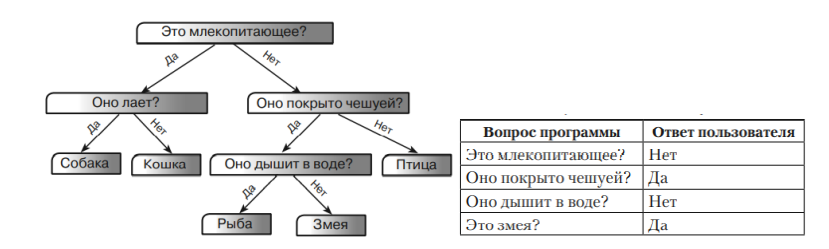

Если задуман жираф, вопросы и ответы прозвучат иначе, а программа добавит в дерево уточняющую информацию и нужное животное.
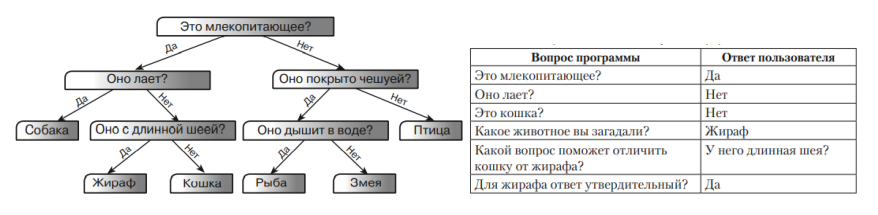

Реализуйте эту игру, используя бинарное дерево для хранения вопросов и ответов.

In [ ]:
class AnimalNode: # м.б. вопросом или животным
    def __init__(self, text, is_question=False):
        self.text = text
        self.is_question = is_question
        self.yes = None  # на ветку "да"
        self.no = None   # на ветку "нет"

def play_game(node):
    # если это вопрос, спрашиваем и идем дальше
    if node.is_question:
        answer = input(f"{node.text} (да/нет): ").lower().strip()
        if answer == 'да':
            node.yes = play_game(node.yes)
        else:
            node.no = play_game(node.no)
        return node
    
    # если это лист (= животное)
    else:
        answer = input(f"Это {node.text}? (да/нет): ").lower().strip()
        if answer == 'да':
            print("Угадано")
            return node
        else:
            # обуч.: получаем данные о новом животном
            new_animal_name = input("Какое животное вы загадали? ").strip()
            print(f"Какой вопрос поможет отличить '{new_animal_name}' от '{node.text}'?")
            new_question_text = input("Введите вопрос: ").strip()
            
            yes_for_new = input(f"Для '{new_animal_name}' ответ (да/нет): ").lower().strip()
            
            # созд. новый узел-вопрос
            new_node = AnimalNode(new_question_text, is_question=True)
            new_animal_node = AnimalNode(new_animal_name)
            
            if yes_for_new == 'да':
                new_node.yes = new_animal_node
                new_node.no = node  # старое животное идет в ветку "нет"
            else:
                new_node.yes = node # старое животное идет в ветку "да"
                new_node.no = new_animal_node
                
            return new_node

# изначальное дерево как на картинках из лабы
root = AnimalNode("Это млекопитающее?", is_question=True)

# левая ветка (млекопит.? => да)
root.yes = AnimalNode("Оно лает?", is_question=True)
root.yes.yes = AnimalNode("Собака")
root.yes.no = AnimalNode("Кошка")

# правая ветка (млекопит.? => нет)
root.no = AnimalNode("Оно покрыто чешуей?", is_question=True)

# оно покрыто чешуей? => да
root.no.yes = AnimalNode("Оно дышит в воде?", is_question=True)
root.no.yes.yes = AnimalNode("Рыба")
root.no.yes.no = AnimalNode("Змея")

# оно покрыто чешуей? => нет
root.no.no = AnimalNode("Птица")

while True:
    print("\nНачинаем")
    root = play_game(root)
    if input("Сыграть еще раз? (да/нет): ").lower().strip() != 'да':
        break



Начинаем
Какой вопрос поможет отличить 'Лемур' от 'Кошка'?

Начинаем
Какой вопрос поможет отличить 'Кенгуру' от 'Лемур'?

Начинаем
Угадано


### № 4
#### **(3 балла)**
Создайте двоичную кучу с ограниченным размером. Другими словами, куча может отслеживать только n важных элементов. Если её размер становится больше, то наименее приоритетный элемент отбрасывается.


In [25]:
# в лекционных материалах есть реализация бинарной кучи,
# поэтому просто её доработаем

# === ИЗ ЛЕКЦИИ
class BinHeap:
    def __init__(self):
        self.heapList = [0]
        self.currentSize = 0

    def percUp(self, i):
        while i // 2 > 0:
            if self.heapList[i] < self.heapList[i // 2]:
                tmp = self.heapList[i // 2]
                self.heapList[i // 2] = self.heapList[i]
                self.heapList[i] = tmp
            i = i // 2

    def insert(self, k):
        self.heapList.append(k)
        self.currentSize = self.currentSize + 1
        self.percUp(self.currentSize)

    def percDown(self, i):
        while (i * 2) <= self.currentSize:
            mc = self.minChild(i)
            if self.heapList[i] > self.heapList[mc]:
                tmp = self.heapList[i]
                self.heapList[i] = self.heapList[mc]
                self.heapList[mc] = tmp
            i = mc

    def minChild(self, i):
        if i * 2 + 1 > self.currentSize:
            return i * 2
        else:
            if self.heapList[i * 2] < self.heapList[i * 2 + 1]:
                return i * 2
            else:
                return i * 2 + 1

    def delMin(self):
        retval = self.heapList[1]
        self.heapList[1] = self.heapList[self.currentSize]
        self.currentSize = self.currentSize - 1
        self.heapList.pop()
        self.percDown(1)
        return retval

    def buildHeap(self, alist):
        i = len(alist) // 2
        self.currentSize = len(alist)
        self.heapList = [0] + alist[:]
        while (i > 0):
            self.percDown(i)
            i = i - 1


# === ДОРАБОТАННАЯ РЕАЛИЗАЦИЯ огр. кучи
class LimitedBinHeap(BinHeap):
    def __init__(self, max_size):
        super().__init__()
        self.max_size = max_size
    
    def insert(self, k):
        if self.currentSize < self.max_size:
            # Куча не заполнена, добавляем элемент обычным способом
            super().insert(k)
        else:
            # Куча заполнена, проверяем приоритет
            if k > self.heapList[1]:     # Если новый элемент важнее минимума
                self.heapList[1] = k     # Заменяем корень
                self.percDown(1)         # Восстанавливаем свойство кучи
                # Иначе элемент отбрасывается
    def __str__(self):
        return str(self.heapList[1:])    # т.к. первый элемент служебный, игнорим его
        
lh = LimitedBinHeap(max_size=3)
print("Создали кучу max_size=3, добавили 5:")
lh.insert(5)
print(lh)
print("Добавили 10:")
lh.insert(10)
print(lh)
print("Добавили 3:")
lh.insert(3)   # Куча: [3, 5, 10]
print(lh)
print("Добавили 8, значит 3 должна уйти и 8 встать на её место:")
lh.insert(8)   # 8 > 3, заменяем 3 → [5, 8, 10]
print(lh)
print("Добавляем 2, она меньше всех эл-ов => ничего не поменяется:")
lh.insert(2)   # 2 < 5, игнорируется
print(lh)
print("Добавляем 15, она больше всех эл-ов => 15 заменит 5:")
lh.insert(15)  # 15 > 5, заменяем 5 → [8, 10, 15]
print(lh)
print("\n")

print("Создали другую кучу,  max_size=5,\nкладём туда [9, 5, 6, 2, 3, 15, 1, 20, 8, 12] в цикле.")
print("Результат: куча содержит 5 наибольших элементов:")
lh2 = LimitedBinHeap(max_size=5)
data = [9, 5, 6, 2, 3, 15, 1, 20, 8, 12]
for value in data:
    lh2.insert(value)
print(lh2)


Создали кучу max_size=3, добавили 5:
[5]
Добавили 10:
[5, 10]
Добавили 3:
[3, 10, 5]
Добавили 8, значит 3 должна уйти и 8 встать на её место:
[5, 10, 8]
Добавляем 2, она меньше всех эл-ов => ничего не поменяется:
[5, 10, 8]
Добавляем 15, она больше всех эл-ов => 15 заменит 5:
[8, 10, 15]


Создали другую кучу,  max_size=5,
кладём туда [9, 5, 6, 2, 3, 15, 1, 20, 8, 12] в цикле.
Результат: куча содержит 5 наибольших элементов:
[8, 9, 12, 20, 15]


### № 5
#### **(3 балла)**
Реализуйте двоичную кучу как max heap на основание варианта min heap из лекционных материалов.

In [26]:
# То же, что в лекции, но поменяли:
#   - В percUp: поднимаем элемент, если он больше родителя.
#   - В percDown: опускаем элемент, если он меньше макс. ребёнка.
#   - maxChild: выбираем ребенка с наиб. знач.

class MaxBinHeap:
    def __init__(self):
        self.heapList = [0]
        self.currentSize = 0

    def percUp(self, i):
        while i // 2 > 0:
            # ИЗМЕНЕНО: если тек. эл. БОЛЬШЕ родителя, меняем местами
            if self.heapList[i] > self.heapList[i // 2]:
                tmp = self.heapList[i // 2]
                self.heapList[i // 2] = self.heapList[i]
                self.heapList[i] = tmp
            i = i // 2

    def insert(self, k):
        self.heapList.append(k)
        self.currentSize = self.currentSize + 1
        self.percUp(self.currentSize)

    def percDown(self, i):
        while (i * 2) <= self.currentSize:
            mc = self.maxChild(i)   # maxChild вместо minChild
            # ИЗМЕНЕНО: если тек. эл. МЕНЬШЕ макс. ребенка, меняем местами
            if self.heapList[i] < self.heapList[mc]:
                tmp = self.heapList[i]
                self.heapList[i] = self.heapList[mc]
                self.heapList[mc] = tmp
            i = mc

    def maxChild(self, i):
        if i * 2 + 1 > self.currentSize:
            return i * 2
        else:
            # Изменено: Выбираем ребенка с БОЛЬШИМ значением
            if self.heapList[i * 2] > self.heapList[i * 2 + 1]:
                return i * 2
            else:
                return i * 2 + 1

    def delMax(self):
        retval = self.heapList[1]
        self.heapList[1] = self.heapList[self.currentSize]
        self.currentSize = self.currentSize - 1
        self.heapList.pop()
        self.percDown(1)
        return retval

    def buildHeap(self, alist):
        i = len(alist) // 2
        self.currentSize = len(alist)
        self.heapList = [0] + alist[:]
        while (i > 0):
            self.percDown(i)
            i = i - 1
            
    # добавлено мной для удобства вывода
    def __str__(self):
        return str(self.heapList[1:])

bh = MaxBinHeap()
bh.buildHeap([2, 3, 5, 6, 9])

print(f"Куча: {bh}")
print(f"delMax: {bh.delMax()}")   # 9
print(f"delMax: {bh.delMax()}")   # 6
print(f"delMax: {bh.delMax()}")   # 5
print(f"Куча: {bh}")

Куча: [9, 6, 5, 2, 3]
delMax: 9
delMax: 6
delMax: 5
Куча: [3, 2]


### № 6
#### **(3 балла)**
Используя класс BinaryHeap из лекционных материалов, реализуйте новый класс очереди с приоритетом PriorityQueue. Он должен содержать конструктор и методы enqueue и dequeue.

In [27]:
# === КУЧА ИЗ ЛЕКЦИИИ
class BinHeap:
    def __init__(self):
        self.heapList = [0]
        self.currentSize = 0

    def percUp(self, i):
        while i // 2 > 0:
            if self.heapList[i] < self.heapList[i // 2]:
                tmp = self.heapList[i // 2]
                self.heapList[i // 2] = self.heapList[i]
                self.heapList[i] = tmp
            i = i // 2

    def insert(self, k):
        self.heapList.append(k)
        self.currentSize = self.currentSize + 1
        self.percUp(self.currentSize)

    def percDown(self, i):
        while (i * 2) <= self.currentSize:
            mc = self.minChild(i)
            if self.heapList[i] > self.heapList[mc]:
                tmp = self.heapList[i]
                self.heapList[i] = self.heapList[mc]
                self.heapList[mc] = tmp
            i = mc

    def minChild(self, i):
        if i * 2 + 1 > self.currentSize:
            return i * 2
        else:
            if self.heapList[i * 2] < self.heapList[i * 2 + 1]:
                return i * 2
            else:
                return i * 2 + 1

    def delMin(self):
        retval = self.heapList[1]
        self.heapList[1] = self.heapList[self.currentSize]
        self.currentSize = self.currentSize - 1
        self.heapList.pop()
        self.percDown(1)
        return retval

    def buildHeap(self, alist):
        i = len(alist) // 2
        self.currentSize = len(alist)
        self.heapList = [0] + alist[:]
        while (i > 0):
            self.percDown(i)
            i = i - 1
    
    # ДОБАВЛЕНО
    def isEmpty(self):
        return self.currentSize == 0
    
class PriorityQueue:
    def __init__(self):
        self.heap = BinHeap()

    def enqueue(self, item):
        self.heap.insert(item)

    def dequeue(self):
        if self.isEmpty():
            raise IndexError("dequeue from empty priority queue")
        return self.heap.delMin()

    def isEmpty(self):
        return self.heap.isEmpty()

    def size(self):
        return self.heap.currentSize
    
    def __str__(self):
        return f"PriorityQueue({str(self.heap.heapList[1:])})"

pq = PriorityQueue()

pq.enqueue(5)
pq.enqueue(1)
pq.enqueue(3)
pq.enqueue(10)

print("Очередь:", pq)

print("pq.dequeue наим.:", pq.dequeue())
print("pq.dequeue следующий:", pq.dequeue())
print("pq.dequeue следующий:", pq.dequeue())

print("Получилось:", pq)

Очередь: PriorityQueue([1, 5, 3, 10])
pq.dequeue наим.: 1
pq.dequeue следующий: 3
pq.dequeue следующий: 5
Получилось: PriorityQueue([10])
